In [6]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def get_dog_kernels(size=5, sigma=2):
    limit = size // 2
    ax = np.arange(-limit, limit + 1)
    xx, yy = np.meshgrid(ax, ax)
    
    g = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    
    # x-direction kernel
    kernel_x = -(xx / (sigma**2)) * g
    
    # y-direction kernel
    kernel_y = -(yy / (sigma**2)) * g
    
    return kernel_x, kernel_y

dog_x, dog_y = get_dog_kernels(size=5, sigma=2)

print("Derivative of Gaussian Kernel - X Direction")
print(np.round(dog_x, 5))

print("\nDerivative of Gaussian Kernel - Y Direction")
print(np.round(dog_y, 5))


Derivative of Gaussian Kernel - X Direction
[[ 0.00732  0.00532 -0.      -0.00532 -0.00732]
 [ 0.01065  0.00775 -0.      -0.00775 -0.01065]
 [ 0.01207  0.00878 -0.      -0.00878 -0.01207]
 [ 0.01065  0.00775 -0.      -0.00775 -0.01065]
 [ 0.00732  0.00532 -0.      -0.00532 -0.00732]]

Derivative of Gaussian Kernel - Y Direction
[[ 0.00732  0.01065  0.01207  0.01065  0.00732]
 [ 0.00532  0.00775  0.00878  0.00775  0.00532]
 [-0.      -0.      -0.      -0.      -0.     ]
 [-0.00532 -0.00775 -0.00878 -0.00775 -0.00532]
 [-0.00732 -0.01065 -0.01207 -0.01065 -0.00732]]


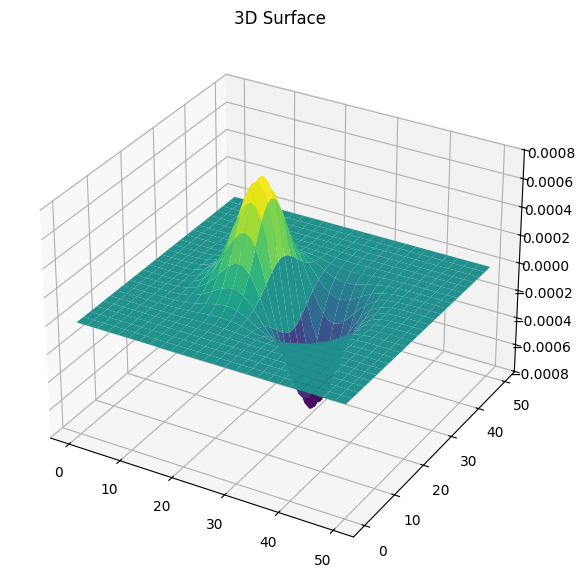

In [ ]:
# (c)
size_l = 51
sigma_l = 5
dog_x_l, _ = get_dog_kernels(size_l, sigma_l)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(size_l), np.arange(size_l))

surf = ax.plot_surface(X, Y, dog_x_l, cmap='viridis', edgecolor='none')
ax.set_title('3D Surface')
plt.show()

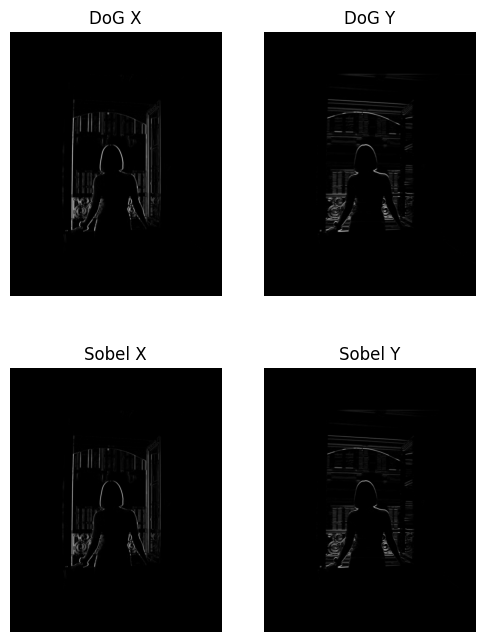

In [17]:
im = cv.imread('images/woman_in_shadow.avif', cv.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

# (d) Manual DoG
grad_x_dog = cv.filter2D(im, cv.CV_64F, dog_x)
grad_y_dog = cv.filter2D(im, cv.CV_64F, dog_y)

# (e) OpenCV Sobel
sobel_x = cv.Sobel(im, cv.CV_64F, 1, 0, ksize=5)
sobel_y = cv.Sobel(im, cv.CV_64F, 0, 1, ksize=5)

titles = ['DoG X', 'DoG Y', 'Sobel X', 'Sobel Y']
images = [grad_x_dog, grad_y_dog, sobel_x,  sobel_y]

plt.figure(figsize=(6, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(np.abs(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()